📊 데이터 분석 진행 중 (SQL 연결 성공)...


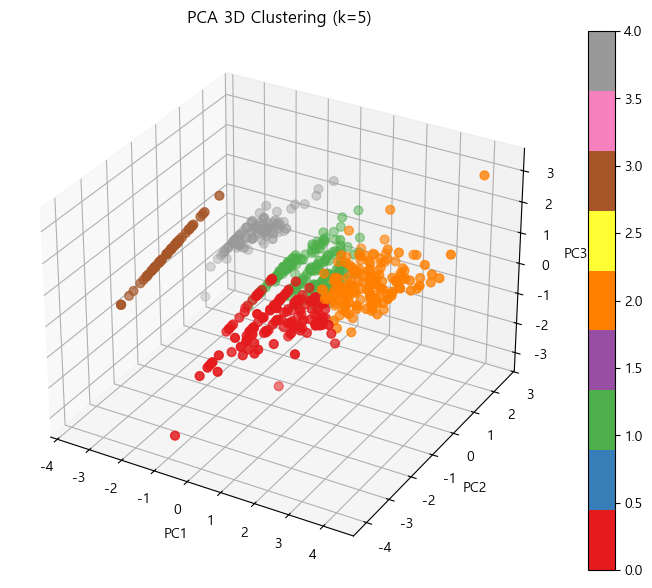

✅ 분석 완료! 실루엣 점수: 0.4230


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

# --- [0. 환경 변수 로드 및 설정] ---
load_dotenv()  # .env 파일의 변수들을 로드합니다

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# [사용자 설정] 군집 수 k와 PCA 차원 수
n_clusters = 5
n_components = 3

# --- [1. 데이터 로드 및 DB 연결] ---
# .env 정보를 사용하여 엔진 생성
db_url = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(db_url)

raw_df = pd.read_csv('전체_역사정보_최종_정제_v58.csv')
coffee_df_raw = pd.read_sql("SELECT 브랜드명, 매장명, 경도, 위도, 지역 FROM coffee_chain", engine)

# 지역 필터링
valid_regions = raw_df['지역'].unique().tolist()
coffee_df = coffee_df_raw[coffee_df_raw['지역'].isin(valid_regions)].copy()

# --- [2. DBSCAN 상권 그룹화] ---
raw_df['총_승하차객수'] = raw_df['1월 승차이용객수'] + raw_df['1월 하차이용객수']
station_base = raw_df.groupby(['지역', '역명']).agg({
    '총_승하차객수': 'sum', '위도': 'mean', '경도': 'mean'
}).reset_index()

coords = np.radians(station_base[['위도', '경도']])
dbscan = DBSCAN(eps=0.8/6371, min_samples=1, metric='haversine')
station_base['상권_ID'] = dbscan.fit_predict(coords)

districts = station_base.groupby('상권_ID').agg({
    '역명': lambda x: ', '.join(x.unique()),
    '지역': 'first', '총_승하차객수': 'sum', '위도': 'mean', '경도': 'mean'
}).reset_index()

# --- [3. 5가지 피처 추출 (점수 및 비율)] ---
premium_brands = ['스타벅스', '투썸플레이스', '폴바셋', '할리스', '파스쿠찌', '공차', '디저트39']
budget_brands = ['메가커피', '빽다방', '컴포즈커피', '더벤티', '메머드커피', '이디야', '던킨도너츠', '하삼동커피']

def get_enhanced_features(row, stores):
    s_lat, s_lon = row['위도'], row['경도']
    nearby = stores[(stores['위도'].between(s_lat - 0.005, s_lat + 0.005)) & 
                    (stores['경도'].between(s_lon - 0.006, s_lon + 0.006))]
    
    total_count = len(nearby)
    p_count = nearby['브랜드명'].isin(premium_brands).sum()
    b_count = nearby['브랜드명'].isin(budget_brands).sum()
    
    p_score = p_count * 3
    b_score = b_count * 1
    p_ratio = p_count / total_count if total_count > 0 else 0
    b_ratio = b_count / total_count if total_count > 0 else 0
    
    return pd.Series([p_score, b_score, p_ratio, b_ratio])

print("📊 데이터 분석 진행 중 (SQL 연결 성공)...")
districts[['프리미엄점수', '가성비점수', '프리미엄비율', '가성비비율']] = districts.apply(
    lambda x: get_enhanced_features(x, coffee_df), axis=1
)

features = ['프리미엄점수', '가성비점수', '프리미엄비율', '가성비비율', '총_승하차객수']
data_for_pca = districts[features]

# --- [4. PCA 및 K-means] ---
scaler = PowerTransformer()
data_scaled = scaler.fit_transform(data_for_pca)

pca = PCA(n_components=n_components)
data_pca = pca.fit_transform(data_scaled)

kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
districts['클러스터'] = kmeans.fit_predict(data_pca)

# --- [5. 시각화] ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2],
                     c=districts['클러스터'], cmap='Set1', s=40)

ax.set_title(f'PCA 3D Clustering (k={n_clusters})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.colorbar(scatter)
plt.show()

print(f"✅ 분석 완료! 실루엣 점수: {silhouette_score(data_pca, districts['클러스터']):.4f}")